# A* Algorithm

Shortest Path:
A -> B -> E -> G
Total Cost: 8


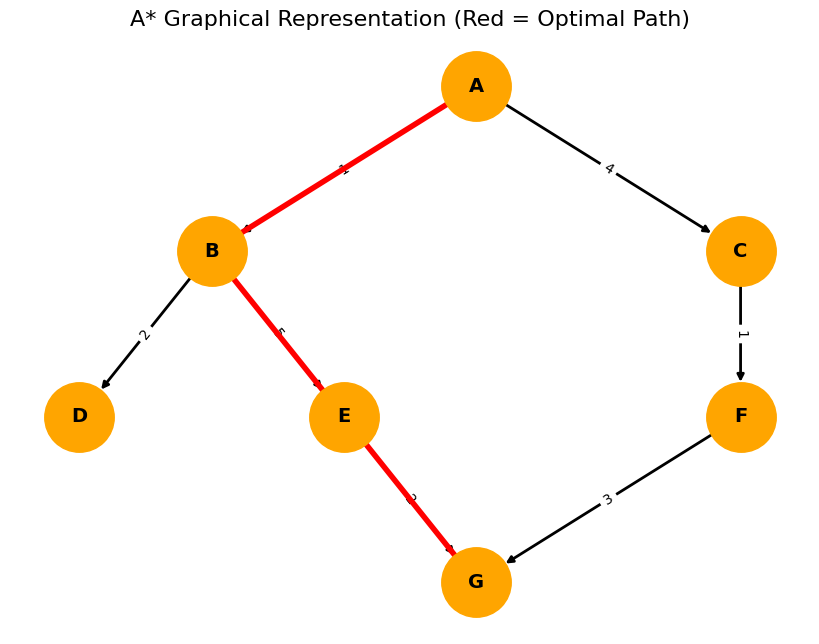

In [4]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Define the Graph with edge costs
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('G', 2)],
    'F': [('G', 3)],
    'G': []
}

# Heuristic values
heuristic = {
    'A': 7,
    'B': 6,
    'C': 2,
    'D': 5,
    'E': 2,
    'F': 1,
    'G': 0
}

# A* Algorithm
def astar(graph, heuristic, start, goal):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()

    while pq:
        f, g, node, path = heapq.heappop(pq)

        if node == goal:
            return path, g

        if node in visited:
            continue

        visited.add(node)

        for neighbor, cost in graph[node]:
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristic[neighbor]
                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return None, float('inf')


# Find shortest path
path, cost = astar(graph, heuristic, 'A', 'G')

if path:
    print("Shortest Path:")
    print(" -> ".join(path))
    print("Total Cost:", cost)
else:
    print("No path found.")

# Create directed graph
G = nx.DiGraph()

for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge(node, neighbor, weight=weight)

# Node positions
pos = {
    'A': (0, 3),
    'B': (-1, 2),
    'C': (1, 2),
    'D': (-1.5, 1),
    'E': (-0.5, 1),
    'F': (1, 1),
    'G': (0, 0)
}

plt.figure(figsize=(8, 6))

# Draw graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='orange',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='black',
    arrows=True,
    width=2
)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Highlight the shortest  path
if path:
    path_edges = list(zip(path[:-1], path[1:]))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=path_edges,
        edge_color='red',
        width=4,
        arrows=True
    )

plt.title("A* Graphical Representation (Red = Optimal Path)", fontsize=16)
plt.axis('off')
plt.show()

# AO* Algorithm

Optimal Path:
A -> C -> F
Total Cost: 6


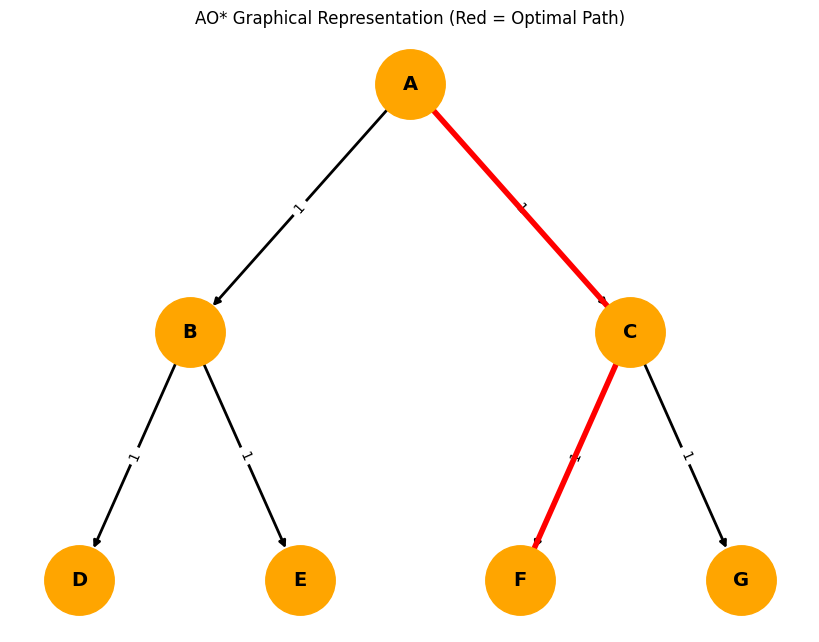

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': {'type': 'OR', 'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
}

# AO* Algorithm
def ao_star(node):
    info = graph[node]

    # Leaf node
    if info['type'] == 'LEAF':
        return info['cost'], [node]

    # OR node
    if info['type'] == 'OR':
        best_cost = float('inf')
        best_path = []

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total = edge_cost + child_cost

            if total < best_cost:
                best_cost = total
                best_path = [node] + child_path

        return best_cost, best_path

    # AND node
    if info['type'] == 'AND':
        total_cost = 0
        full_path = [node]

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path

        return total_cost, full_path


# Run AO*
cost, path = ao_star('A')

print("Optimal Path:")
print(" -> ".join(path))
print("Total Cost:", cost)

G = nx.DiGraph()

for node, info in graph.items():
    if 'children' in info:
        for child, weight in info['children']:
            G.add_edge(node, child, weight=weight)

pos = {
    'A': (0, 3),
    'B': (-1, 2),
    'C': (1, 2),
    'D': (-1.5, 1),
    'E': (-0.5, 1),
    'F': (0.5, 1),
    'G': (1.5, 1)
}

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="orange",
    node_size=2500,
    font_size=14,
    font_weight="bold",
    edge_color="black",
    arrows=True,
    width=2
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

path_edges = list(zip(path[:-1], path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=4,
    arrows=True
)

plt.title("AO* Graphical Representation (Red = Optimal Path)")
plt.axis("off")
plt.show()